# Objectives
This notebook showcases the two two ways implemented to get an idea of the data we are dealing with. 
More specifically, the use of the functions:

- *plot_parameters_error_bounds*

- *get_allan_index*

- *Get_All_Outputs*

is showcased. 

## Plotting a single fdets file
First, we initialize the object_fdets object and extract the data.
Then, we use the extracted data to visualize some information and get an idea of "how close" our data follows the white noise.

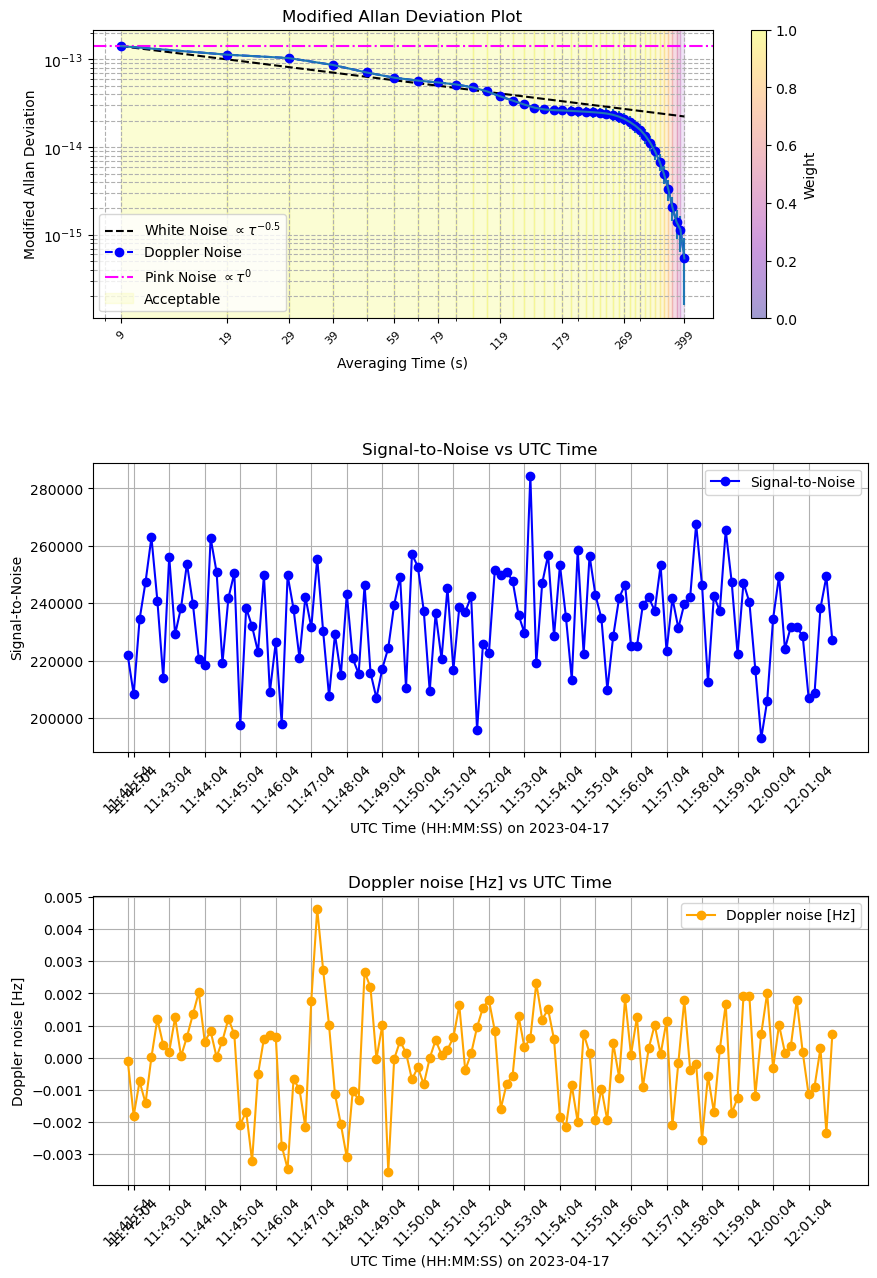

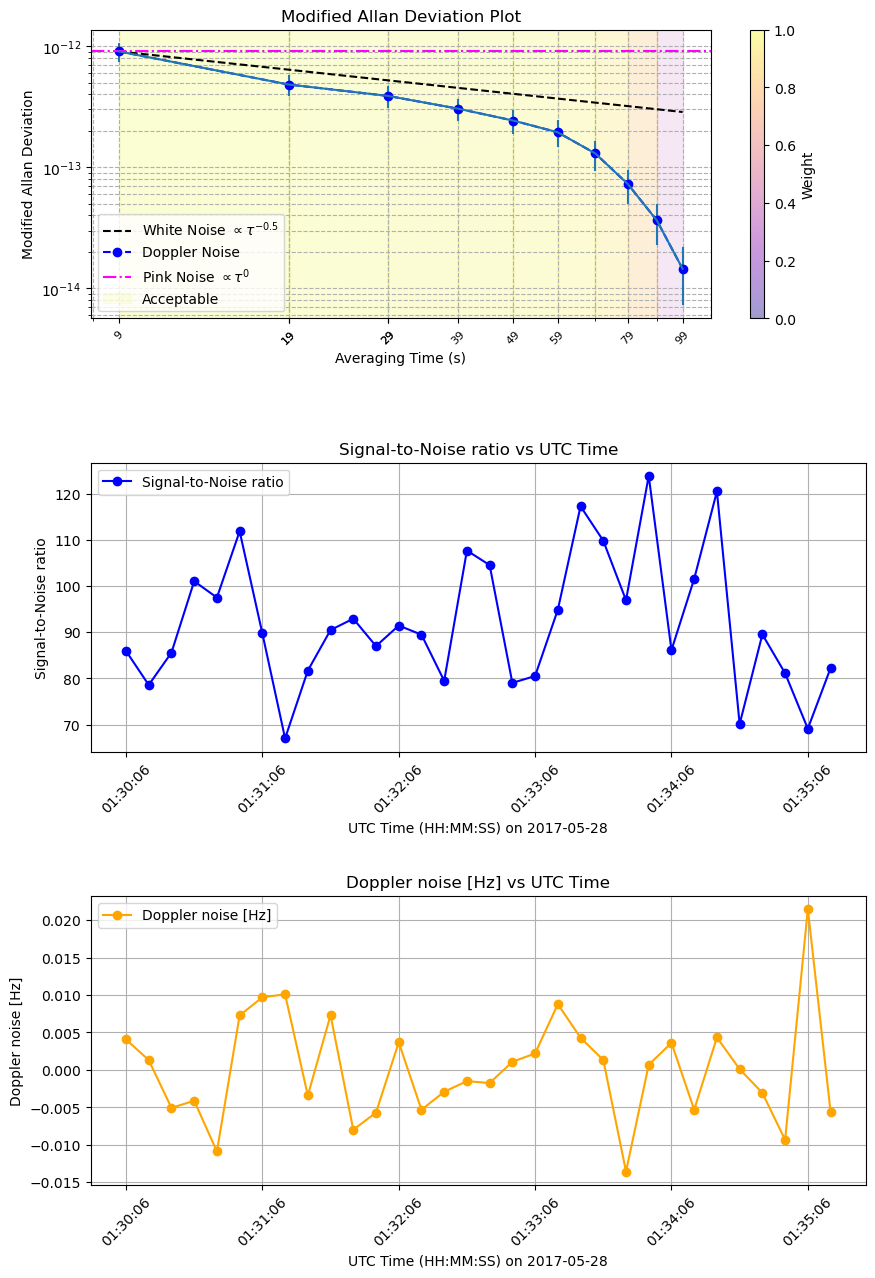

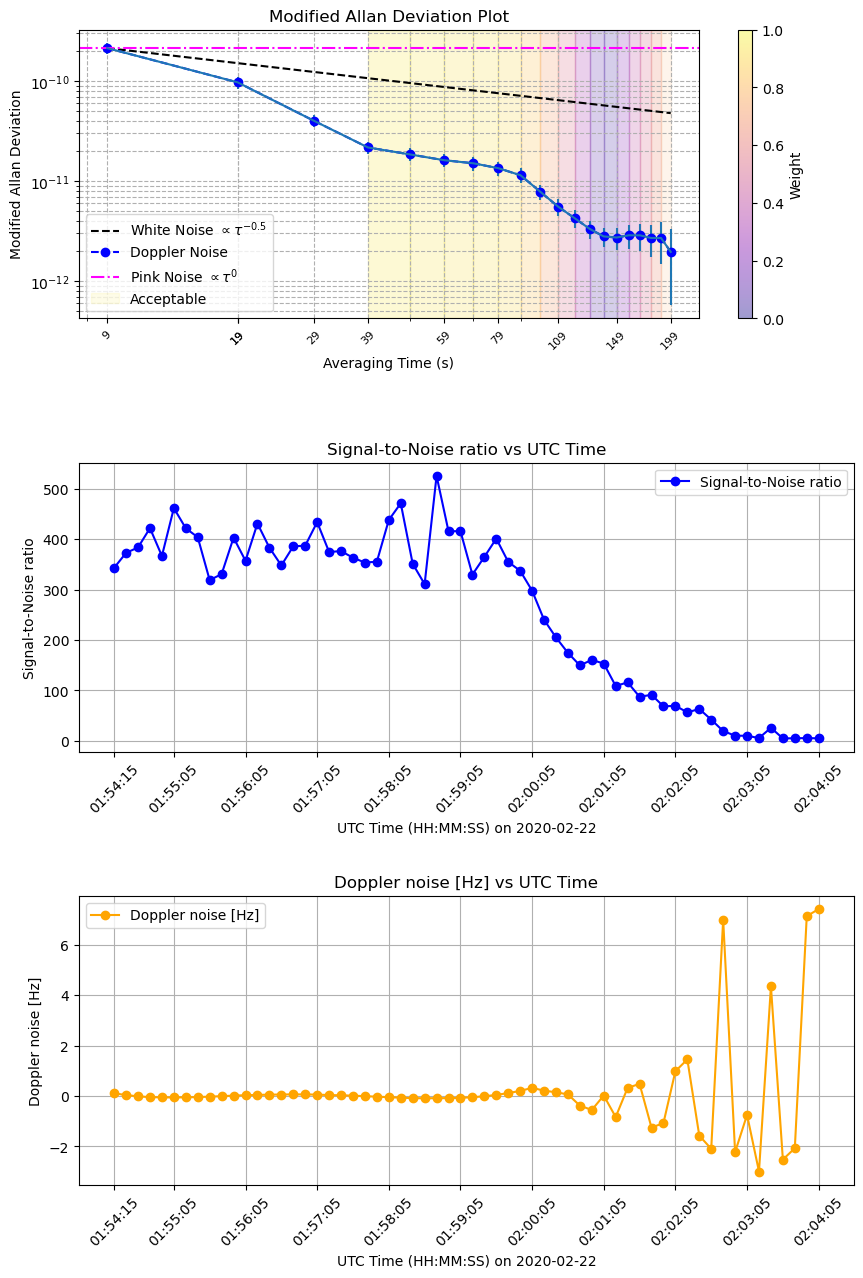

In [6]:
from Allan_Slope_Library import Allan_Utility_Functions
object = Allan_Utility_Functions()
object_fdets = object.ProcessFdets()

extracted_data_1 = object_fdets.extract_parameters('/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/juice/jc230417/Hbe/dop1/Fdets.jui2023.04.17.Hb.0005.r2i.txt', JUICE = True)
extracted_data_2 = object_fdets.extract_parameters('/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/insight/ED045A/Fdets.min2020.02.22.Bd.0001.r2i.txt', JUICE = False)
extracted_data_3 = object_fdets.extract_parameters('/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/insight/ED045A/Fdets.min2020.02.22.T6.0005.r2i.txt', JUICE = False)

object_fdets.plot_parameters_error_bounds(extracted_data_1, suppress = False)
object_fdets.plot_parameters_error_bounds(extracted_data_2, suppress = False)
object_fdets.plot_parameters_error_bounds(extracted_data_3, suppress = False)

# Getting the Allan Index
Looking at the above 3 Modified Allan Deviation plots, it looks like the first two better "follow" the white noise, while the last one looks a bit off. 
Let's see if the *get_allan_index* function confirms this. 
As you can see from the output of the following cell, the third allan index is the lowest one, while the first two are closer to 1. Confirmed!

In [12]:
first = object_fdets.get_allan_index(extracted_data_1, save_dir = '/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/juice/jc230417/Hbe/dop1/Fdets.jui2023.04.17.Hb.0005.r2i',suppress = False)

second = object_fdets.get_allan_index(extracted_data_2, save_dir = '/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/insight/ED045A/Fdets.min2020.02.22.Bd.0001.r2i',suppress = False)
third = object_fdets.get_allan_index(extracted_data_3, save_dir = '/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/insight/ED045A/Fdets.min2020.02.22.T6.0005.r2i',suppress = False)

print(f'First Allan Index: {first}')
print(f'Second Allan Index: {second}')

print(f'Third Allan Index: {third}')

Saved Allan index data to: /Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/juice/jc230417/Hbe/dop1/Fdets.jui2023.04.17.Hb.0005.r2i/allan_index.txt


Saved Allan index data to: /Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/insight/ED045A/Fdets.min2020.02.22.Bd.0001.r2i/allan_index.txt


Saved Allan index data to: /Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/insight/ED045A/Fdets.min2020.02.22.T6.0005.r2i/allan_index.txt


First Allan Index: 0.9542043122561699
Second Allan Index: 1.0037069047504859
Third Allan Index: 0.5430337113538422


## Saving the Plots (JUICE)
The function *Get_All_Outputs(root_folder, JUICE)* allows to create and save the plots. 
If JUICE = None: Assumes old format for time epochs, else: assumes MEX/Insight type. 

If save_plots = True: saves the mADEV plots
If save_index = True: creates Allan Index files and saves them

The following cell creates all the Allan Deviation and SNR plots in each *dataset/juice* folder.
Uncomment it only if replotting is necessary

In [14]:
#root_folder = '/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/juice'
#object_fdets.Get_All_Outputs(root_folder, JUICE = True, save_index = True, save_plots = False)

## Saving the Plots (MEX)
The following cell creates all the Allan Deviation and SNR plots in each *dataset/Insight* folder.

If save_plots = True: saves the mADEV plots
If save_index = True: creates Allan Index files and saves them

Uncomment it only if replotting is necessary

In [15]:
#root_folder = '/Users/lgisolfi/Desktop/data_archiving-1.0/small_dataset/Insight'
#object_fdets.Get_All_Outputs(root_folder, JUICE = False, save_plots = True, save_index = False)